# Stitching redesign, step 4: solve every FOV's position

The affine is the same for every FOV. Each FOV can still sit a little off
(stage repeatability). Solve all positions at once so every kept edge is
matched as closely as possible, with a weak pull toward the affine on every
grid edge (so a FOV with few or failed edges follows the affine, not the
nominal grid). FOV 0 is held fixed.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_04_solve_positions"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


In [2]:
geom = json.loads((DATA_DIR / "geometry.json").read_text())
PX, STEP, FRAME = geom["pixel_um"], geom["step_um"], geom["frame_px"]
nominal = np.loadtxt(DATA_DIR / "positions.txt", delimiter=",")
NBHD = np.array(geom["neighbourhood"])          # 3x3 FOV ids, row 0 = top
new_df = pd.read_csv(DATA_DIR / "edges_remeasured.csv")
edges = L.Edges(new_df, nominal)
print(f"{len(nominal)} FOVs, {len(new_df)} edges, pixel {PX} um, step {STEP:.3f} um, "
      f"3x3 centre FOV {NBHD[1, 1]}")


476 FOVs, 894 edges, pixel 0.109 um, step 199.066 um, 3x3 centre FOV 221


In [3]:
def draw_edges(ax, P, idx, values, cmap, vmin, vmax, lw=2.0):
    """Segments between FOV centres for edges idx, coloured by values."""
    half = FRAME * PX / 2
    seg = np.stack([P[edges.i[idx]] + half, P[edges.j[idx]] + half], axis=1)
    lc = LineCollection(seg, cmap=cmap, linewidths=lw)
    lc.set_array(np.asarray(values)); lc.set_clim(vmin, vmax)
    ax.add_collection(lc)
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")
    return lc


def mark_nbhd(ax, P, color="k"):
    """Outline the 3x3 neighbourhood on a whole-grid plot."""
    ids = NBHD.ravel()
    x0, y0 = P[ids, 0].min(), P[ids, 1].min()
    x1, y1 = P[ids, 0].max() + FRAME * PX, P[ids, 1].max() + FRAME * PX
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=color, lw=2, ls="--"))


def draw_boxes(ax, P, color, lw=0.6, alpha=1.0):
    for p in P:
        ax.add_patch(mpatches.Rectangle(p, FRAME * PX, FRAME * PX, fill=False, ec=color, lw=lw, alpha=alpha))
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")


In [4]:
nb = np.load(DATA_DIR / "neighbourhood_frames.npz")
BEADS = {int(f): nb[f"beads_{f}"] for f in NBHD.ravel()}
DAPI = {int(f): nb[f"dapi_{f}"] for f in NBHD.ravel()}
PARITY = {int(NBHD[r, c]): (r + c) % 2 for r in range(3) for c in range(3)}
CTR = int(NBHD[1, 1])


def corner_views(position_sets, frames=BEADS, half_um=12.0):
    """Render the 4 corners of the centre FOV (where 4 tiles overlap) for
    each position set. Positions are re-referenced to the centre FOV so
    every panel shows the same place."""
    corners = {"up_left": (0, 1), "up_right": (1, 1), "down_left": (0, 0), "down_right": (1, 0)}
    fig, axes = plt.subplots(len(position_sets), 4, figsize=(16, 4.1 * len(position_sets)), squeeze=False)
    for r, (name, P) in enumerate(position_sets.items()):
        Q = P - P[CTR] + nominal[CTR]
        for c, (cname, (sx, sy)) in enumerate(corners.items()):
            # corner of the centre tile's overlap with its neighbours
            cx = nominal[CTR, 0] + (STEP + (FRAME * PX - STEP) / 2 if sx else (FRAME * PX - STEP) / 2)
            cy = nominal[CTR, 1] + (STEP + (FRAME * PX - STEP) / 2 if sy else (FRAME * PX - STEP) / 2)
            rgb, ext = L.render_tiles(frames, {f: (*Q[f], PARITY[f]) for f in frames}, PX,
                                      bounds=(cx - half_um, cy - half_um, cx + half_um, cy + half_um))
            ax = axes[r, c]
            ax.imshow(rgb, extent=ext, origin="lower", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(cname)
            if c == 0:
                ax.set_ylabel(name, fontsize=LABEL_FS + 2)
    return fig


In [5]:
LAM = 1e-3
keep = np.load(DATA_DIR / "keep.npy"); kidx = np.where(keep)[0]
A = np.load(DATA_DIR / "A.npy")
t0 = time.time()
P = L.solve_positions(edges, kidx, nominal, A, LAM, STEP)
print(f"solved {len(P)} positions in {time.time() - t0:.2f}s")
np.savetxt(DATA_DIR / "positions_final.txt", P, delimiter=",", fmt="%.4f")
P_aff = L.apply_affine(A, nominal)
err = {n: L.edge_error(Q, edges, kidx) for n, Q in [("nominal", nominal), ("affine", P_aff), ("final", P)]}
for n, e in err.items():
    print(f"{n:8s} edge misfit: median {np.median(e):.3f}, p90 {np.percentile(e, 90):.3f}, max {e.max():.2f} um")
dev = np.hypot(*(P - P_aff).T)
print(f"|final - affine|: median {np.median(dev):.2f}, p90 {np.percentile(dev, 90):.2f}, max {dev.max():.2f} um")
print(f"|final - nominal| max {np.hypot(*(P - nominal).T).max():.1f} um")
print("rejected edges: misfit at final positions, median "
      f"{np.median(L.edge_error(P, edges, np.where(~keep)[0])):.2f} um")

solved 476 positions in 0.16s
nominal  edge misfit: median 4.484, p90 5.904, max 6.38 um
affine   edge misfit: median 0.612, p90 1.817, max 2.14 um
final    edge misfit: median 0.018, p90 0.040, max 0.10 um
|final - affine|: median 1.42, p90 2.18, max 2.56 um
|final - nominal| max 141.0 um
rejected edges: misfit at final positions, median 0.05 um


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_04_solve_positions/nbhd_corners_affine_vs_final.png


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_04_solve_positions/nbhd_corners_dapi_nominal_vs_final.png


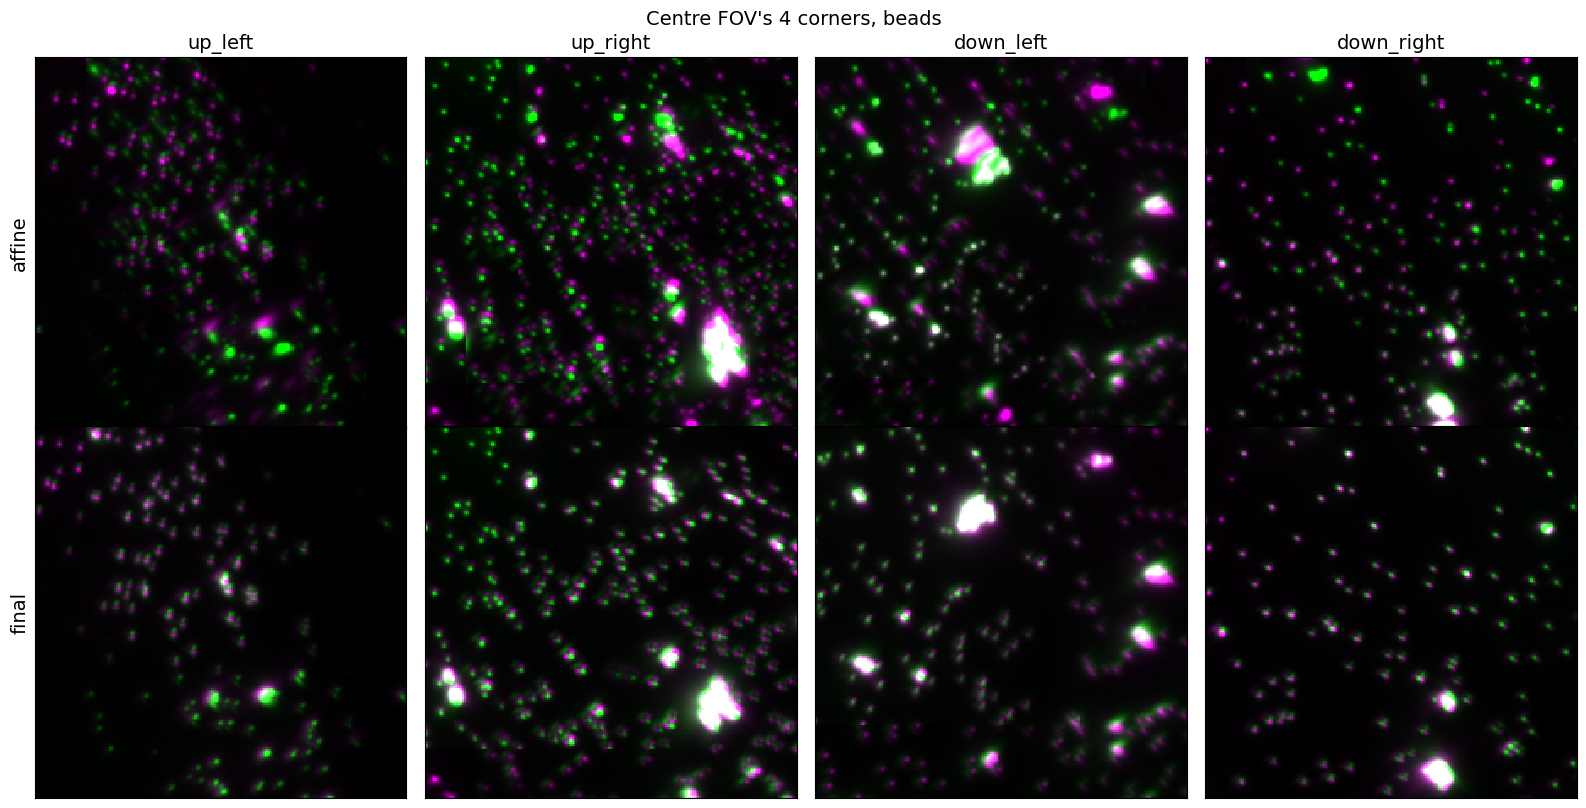

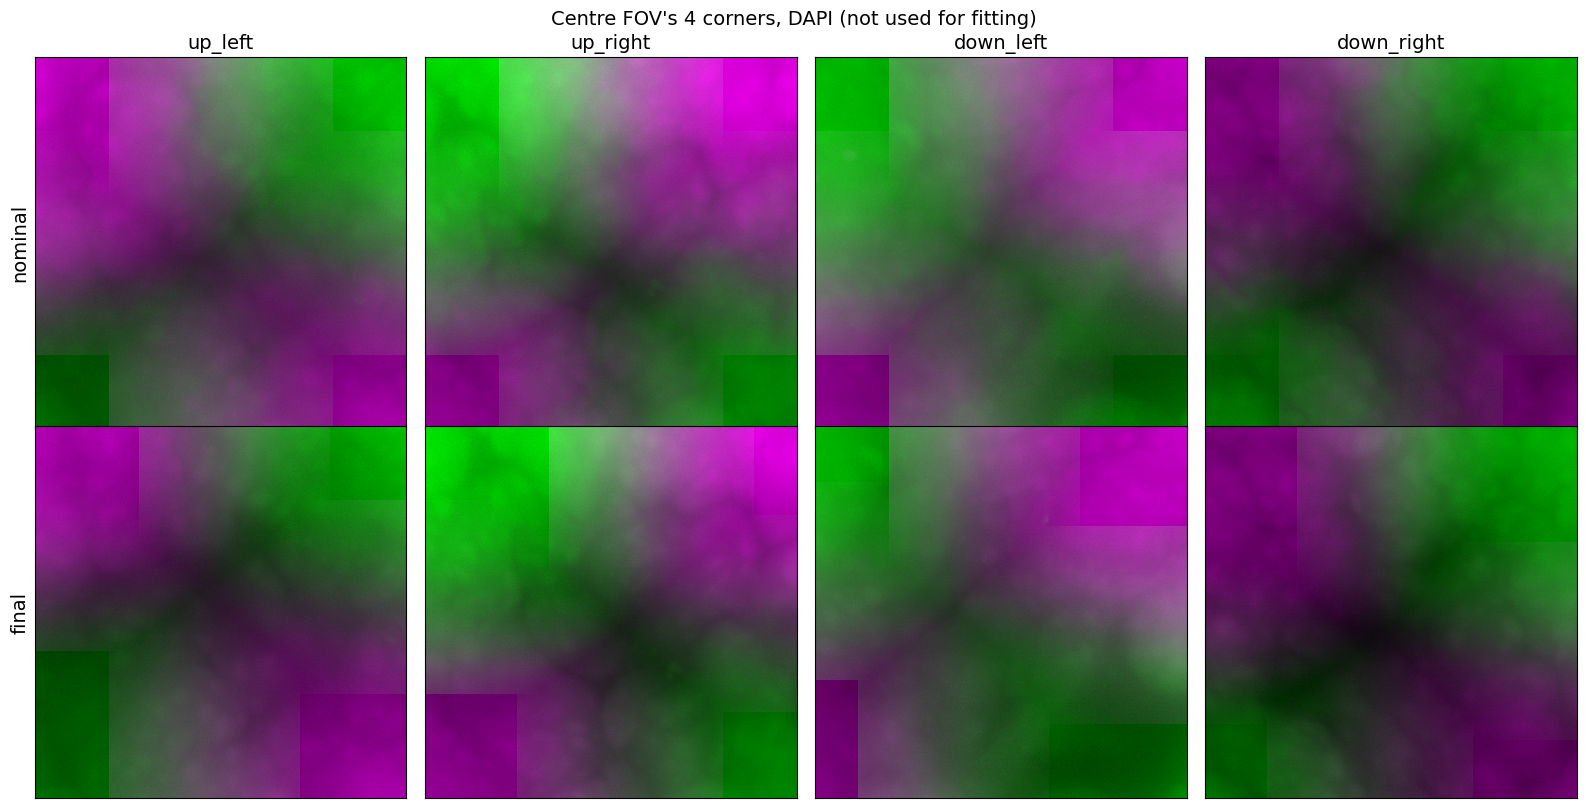

In [6]:
fig = corner_views({"affine": P_aff, "final": P})
fig.suptitle("Centre FOV's 4 corners, beads", fontsize=TITLE_FS)
fig.tight_layout(); save(fig, "nbhd_corners_affine_vs_final")
fig = corner_views({"nominal": nominal, "final": P}, frames=DAPI, half_um=20)
fig.suptitle("Centre FOV's 4 corners, DAPI (not used for fitting)", fontsize=TITLE_FS)
fig.tight_layout(); save(fig, "nbhd_corners_dapi_nominal_vs_final")

saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_04_solve_positions/grid_edge_misfit_three.png


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_04_solve_positions/grid_final_boxes_and_per_fov.png


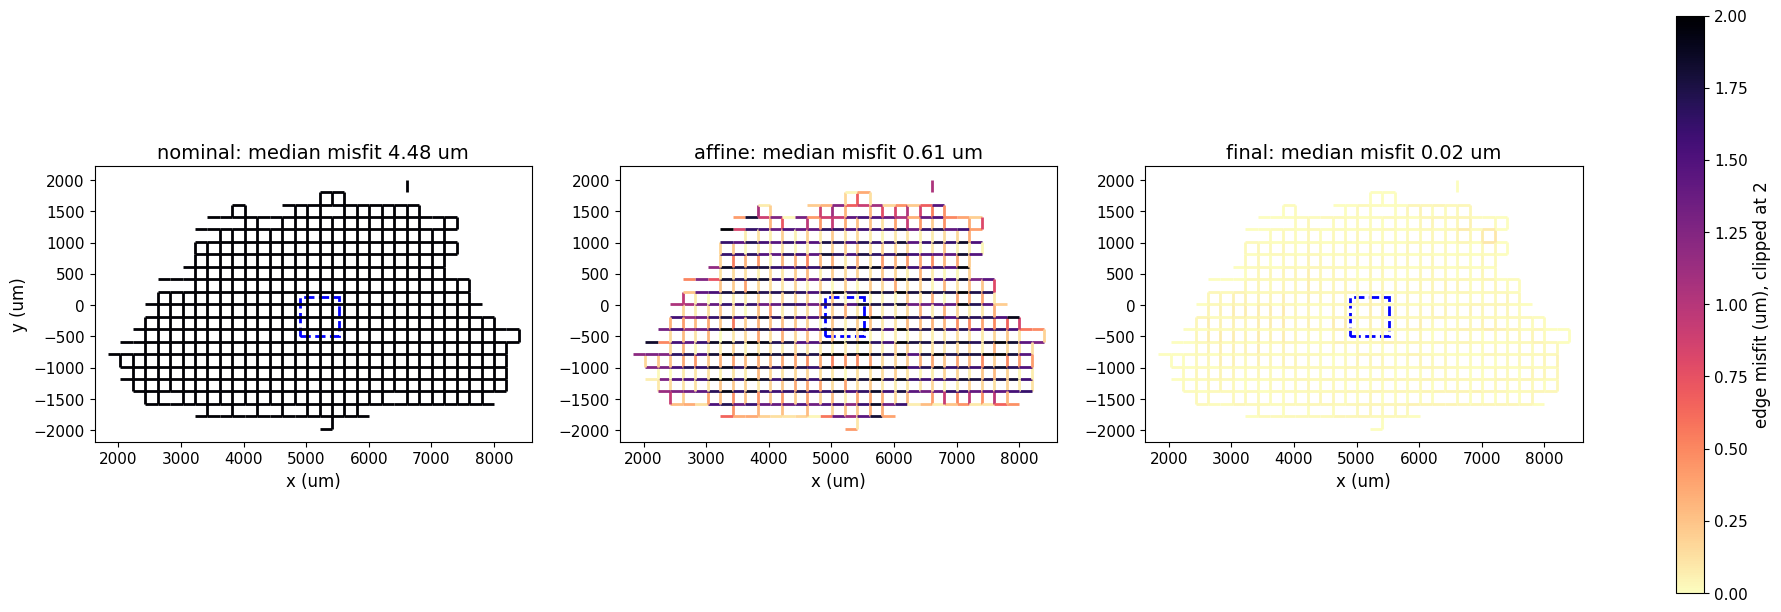

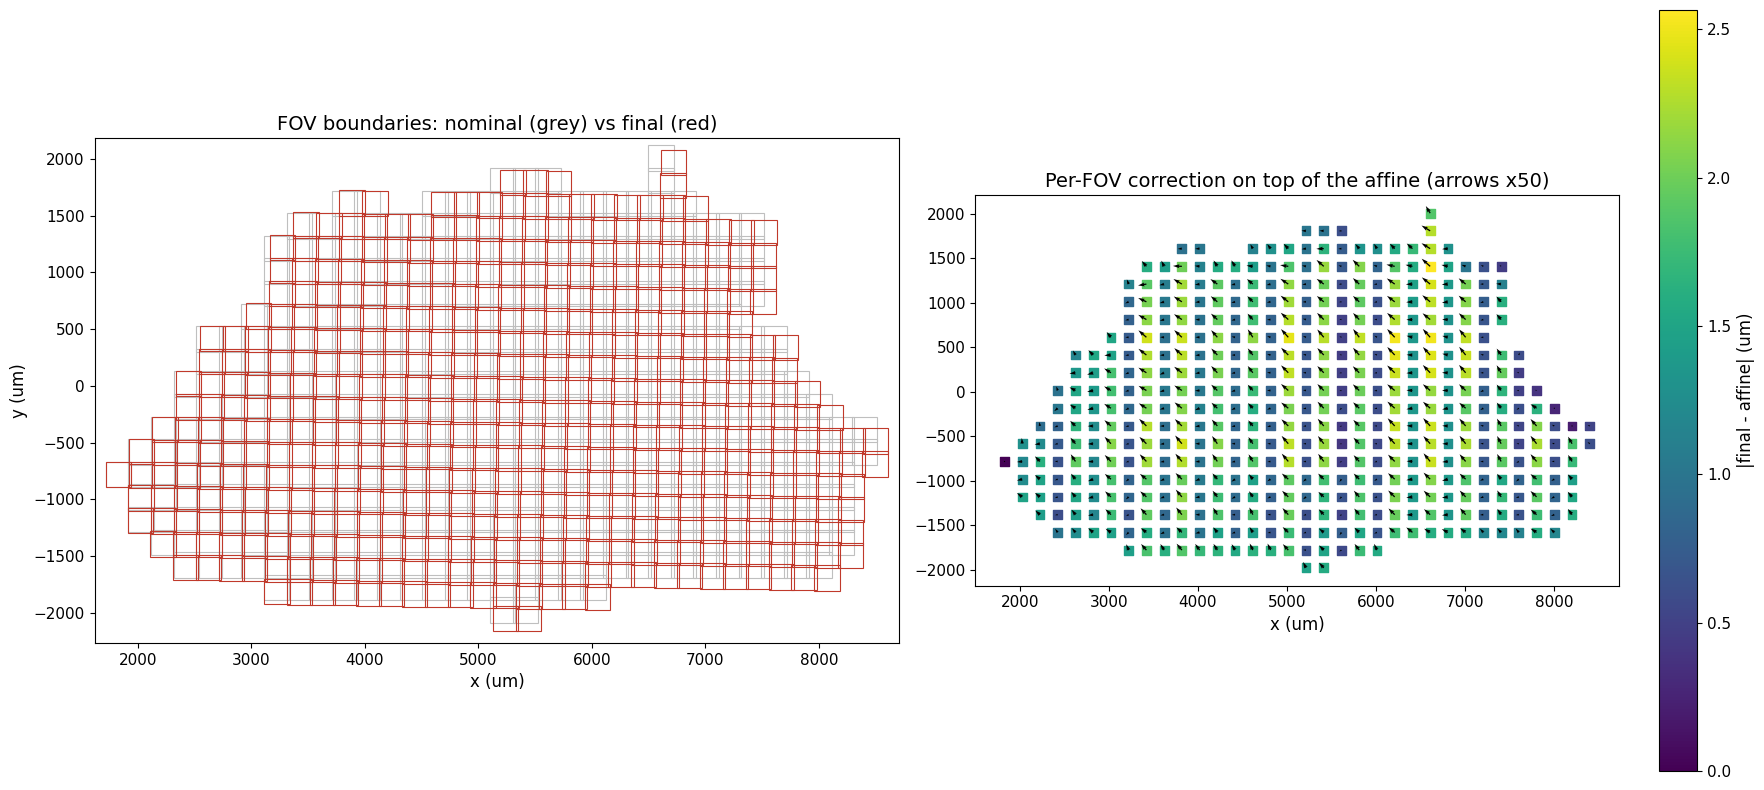

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(24, 7.5))
vmax = 2
for a, n in zip(ax, ["nominal", "affine", "final"]):
    lc = draw_edges(a, nominal, kidx, err[n], "magma_r", 0, vmax, lw=2)
    mark_nbhd(a, nominal, "b")
    a.set_title(f"{n}: median misfit {np.median(err[n]):.2f} um"); a.set_xlabel("x (um)")
ax[0].set_ylabel("y (um)")
fig.colorbar(lc, ax=ax, label="edge misfit (um), clipped at 2")
save(fig, "grid_edge_misfit_three")
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
draw_boxes(ax[0], nominal, "0.75", lw=0.8); draw_boxes(ax[0], P, "#c0392b", lw=0.8)
ax[0].set_title("FOV boundaries: nominal (grey) vs final (red)"); ax[0].set_xlabel("x (um)"); ax[0].set_ylabel("y (um)")
sc = ax[1].scatter(*(nominal + FRAME * PX / 2).T, c=dev, cmap="viridis", s=40, marker="s")
ax[1].quiver(*(nominal + FRAME * PX / 2).T, *(P - P_aff).T, angles="xy", scale_units="xy", scale=0.02, width=0.002)
ax[1].set_aspect("equal"); fig.colorbar(sc, ax=ax[1], label="|final - affine| (um)")
ax[1].set_title("Per-FOV correction on top of the affine (arrows x50)"); ax[1].set_xlabel("x (um)")
fig.tight_layout(); save(fig, "grid_final_boxes_and_per_fov")

### What the per-FOV part is: scan-direction backlash

The grid is scanned in a serpentine: alternate columns go up, then down.
If the stage lands slightly differently depending on the direction it
arrived from, whole columns shift in y, alternating.

scan direction by column (first 12): [0, 1, -1, 1, -1, 1, -1, 1, -1, 1, -1, 1]
y residual of horizontal edges (left -> right column), um:
                   median   std  count
left column scans                     
down                 -4.8  0.55    226
up                   -1.8  0.65    227
final - affine, y: up-scanned columns median -0.09 um, down-scanned +1.35 um


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_04_solve_positions/backlash_by_scan_direction.png


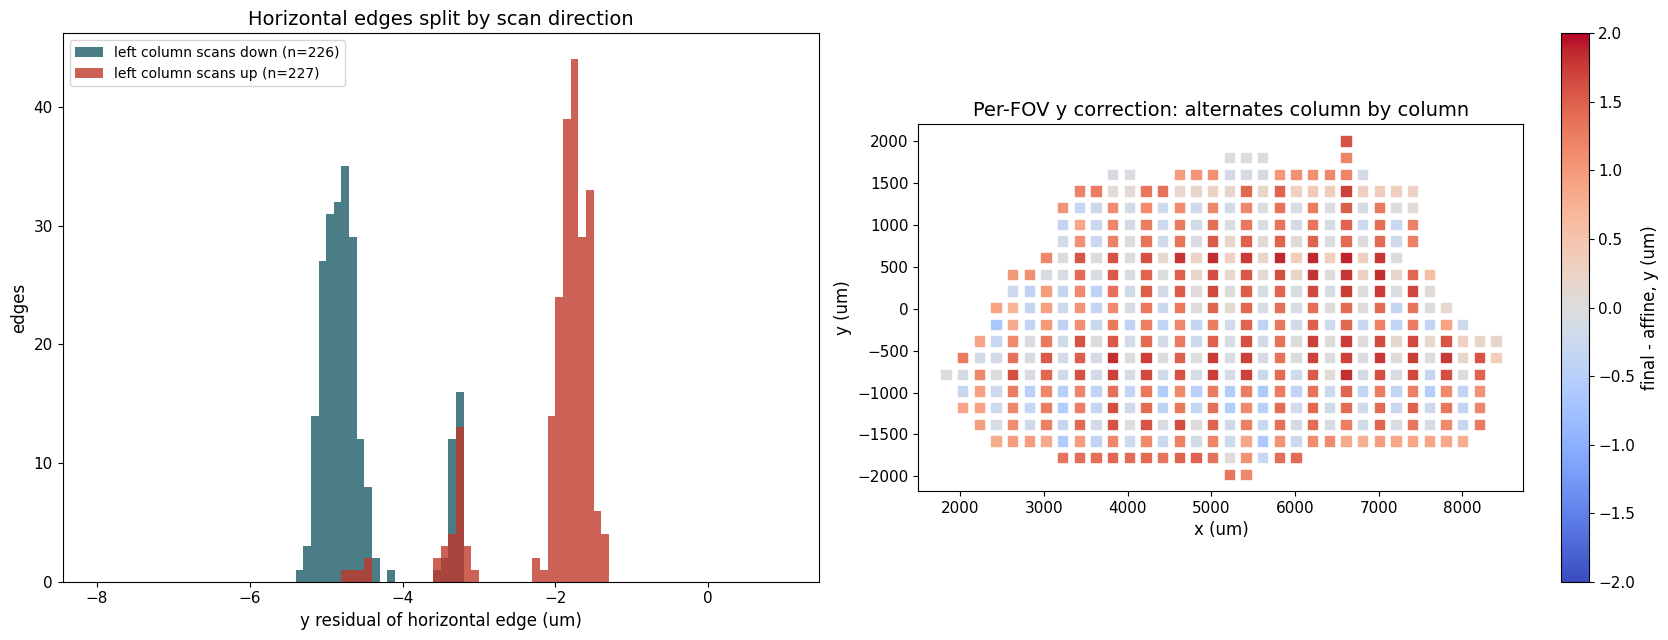

In [8]:
col = np.round((nominal[:, 0] - nominal[:, 0].min()) / STEP).astype(int)
same_col = np.r_[False, np.diff(col) == 0]
dy_seq = np.r_[np.nan, np.diff(nominal[:, 1])]
scan = {c: np.sign(np.nanmedian(dy_seq[(col == c) & same_col])) if ((col == c) & same_col).any() else 0.0
        for c in np.unique(col)}
fov_scan = np.array([scan[c] for c in col])
print("scan direction by column (first 12):", [int(scan[c]) for c in sorted(scan)][:12])
# horizontal edges, expressed left column -> right column
h = np.where(np.isin(edges.direction, ["right", "left"]) & keep)[0]
sgn = np.where(edges.direction[h] == "right", 1, -1)
ry_lr = edges.r[h, 1] * sgn
left_fov = np.where(sgn > 0, edges.i[h], edges.j[h])
tab = pd.DataFrame({"left column scans": np.where(fov_scan[left_fov] > 0, "up", "down"), "ry": ry_lr})
print("y residual of horizontal edges (left -> right column), um:")
print(tab.groupby("left column scans").ry.agg(["median", "std", "count"]).round(2))
res_y = (P - P_aff)[:, 1]
print(f"final - affine, y: up-scanned columns median {np.median(res_y[fov_scan > 0]):+.2f} um, "
      f"down-scanned {np.median(res_y[fov_scan < 0]):+.2f} um")
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5))
for lab, c in [("down", "#1d5c68"), ("up", "#c0392b")]:
    v = tab.ry[tab["left column scans"] == lab]
    ax[0].hist(v, bins=np.linspace(-8, 1, 91), alpha=0.8, color=c, label=f"left column scans {lab} (n={len(v)})")
ax[0].set_xlabel("y residual of horizontal edge (um)"); ax[0].set_ylabel("edges"); ax[0].legend()
ax[0].set_title("Horizontal edges split by scan direction")
sc = ax[1].scatter(*(nominal + FRAME * PX / 2).T, c=res_y, cmap="coolwarm", vmin=-2, vmax=2, s=45, marker="s")
fig.colorbar(sc, ax=ax[1], label="final - affine, y (um)")
ax[1].set_aspect("equal"); ax[1].set_xlabel("x (um)"); ax[1].set_ylabel("y (um)")
ax[1].set_title("Per-FOV y correction: alternates column by column")
fig.tight_layout(); save(fig, "backlash_by_scan_direction")

## Notes (numbers quoted by the HTML)

- LAM = 1e-3; 476 positions solved in 0.34 s.
- Edge misfit on kept edges: nominal median 4.484 / p90 5.904; affine 0.612 / 1.817; final 0.018 / 0.040 (max 0.10) um.
- |final - affine|: median 1.42, p90 2.18, max 2.56 um. |final - nominal| max 141.0 um.
- Rejected edges fit the final positions to a median 0.05 um.
- Serpentine scan. Horizontal-edge y residual: left column scanning down -4.8 um (n=226), up -1.8 um (n=227).
  final - affine in y: up-scanned columns -0.09 um, down-scanned +1.35 um.